In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Convolution2D,MaxPooling2D, Dense, Flatten
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.backend import clear_session

In [2]:
data_dir = "../data"
train_dir = data_dir+"/train"
test_dir = data_dir+"/test"

In [3]:
# For split the data to specified classes
try:
    for fnames in os.listdir(train_dir):
        src = os.path.join(train_dir,fnames)
        classes = fnames.split('.')[0]
        folder = os.path.join(train_dir,classes)
        if not(os.path.exists(folder)):
            os.mkdir(folder)
        des = os.path.join(folder,fnames)
        os.rename(src,des)
except:
    print("The data already splitted")

The data already splitted


In [4]:
datagen = ImageDataGenerator(rescale = 1/255,
                             rotation_range=40,
                             shear_range=0.2,
                             horizontal_flip=True,
                             zoom_range=0.2,
                             validation_split=0.2)
target = (60,60)

train_set = datagen.flow_from_directory(train_dir,
                                        shuffle=True,
                                        target_size = target,
                                        batch_size = 64,
                                        class_mode = 'binary',
                                        subset = 'training')

valid_set = datagen.flow_from_directory(train_dir,
                                        shuffle=True,
                                        target_size = target,
                                        batch_size = 32,
                                        class_mode = 'binary',
                                        subset = 'validation')

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [15]:
clear_session()

model = Sequential([
    Convolution2D(16,3,input_shape=(60,60,3),activation='relu'),
    MaxPooling2D(2),
    Convolution2D(32,3,activation='relu'),
    MaxPooling2D(2),
    Convolution2D(64,3,activation='relu'),
    MaxPooling2D(2),
    Flatten(),
    Dense(512,activation='relu'),
    Dense(1,activation='sigmoid')
])
model.summary()

opt = SGD(learning_rate = 0.05,
                     momentum = 0.9,
                     nesterov = True)
model.compile(loss='binary_crossentropy',optimizer=opt,metrics=['acc'])
model.optimizer.get_config()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 58, 58, 16)        448       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 29, 29, 16)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 27, 27, 32)        4640      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 13, 13, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 11, 11, 64)        18496     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 5, 5, 64)          0         
_________________________________________________________________
flatten (Flatten)            (None, 1600)              0

{'name': 'SGD',
 'learning_rate': 0.05,
 'decay': 0.0,
 'momentum': 0.9,
 'nesterov': True}

In [16]:
history = model.fit(train_set,
                    validation_data=valid_set,
                    steps_per_epoch=train_set.n//train_set.batch_size,
                    validation_steps=valid_set.n//valid_set.batch_size,
                    epochs = 15)

Epoch 1/15
312/312 [==============================] - 56s 178ms/step - loss: 0.6771 - acc: 0.5683 - val_loss: 0.7586 - val_acc: 0.5365
Epoch 2/15
312/312 [==============================] - 58s 185ms/step - loss: 0.6280 - acc: 0.6476 - val_loss: 0.5896 - val_acc: 0.6871
Epoch 3/15
312/312 [==============================] - 55s 178ms/step - loss: 0.5849 - acc: 0.6941 - val_loss: 0.5529 - val_acc: 0.7153
Epoch 4/15
312/312 [==============================] - 56s 179ms/step - loss: 0.5531 - acc: 0.7162 - val_loss: 0.5164 - val_acc: 0.7452
Epoch 5/15
312/312 [==============================] - 54s 172ms/step - loss: 0.5300 - acc: 0.7375 - val_loss: 0.5267 - val_acc: 0.7392
Epoch 6/15
312/312 [==============================] - 55s 176ms/step - loss: 0.5137 - acc: 0.7431 - val_loss: 0.4943 - val_acc: 0.7574
Epoch 7/15
312/312 [==============================] - 60s 193ms/step - loss: 0.4905 - acc: 0.7613 - val_loss: 0.4949 - val_acc: 0.7580
Epoch 8/15
312/312 [==============================] - 5

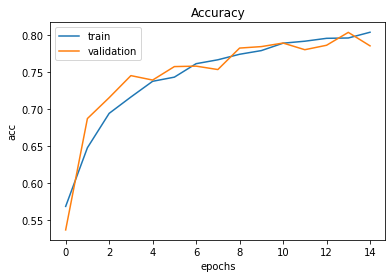

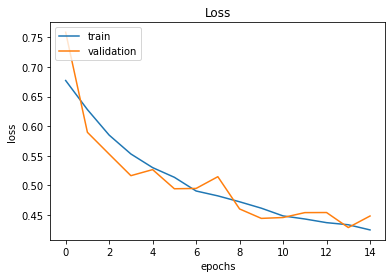

In [17]:
legend = ['train','validation']

plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title("Accuracy")
plt.xlabel("epochs")
plt.ylabel("acc")
plt.legend(legend,loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(legend,loc='upper left')
plt.show()

In [18]:
model.save('my_model')

INFO:tensorflow:Assets written to: my_model\assets


In [9]:
model = load_model('my_model')

In [19]:
def pred(img_path,plot=False):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    
    resize_img = cv2.resize(img,target)
    resize_img = resize_img/255
    
    bat = np.array([resize_img])
    probability = model.predict(bat)
    
    title = "Dog"
    if (probability<0.5):
        title = "Cat"
    
    if (plot):
        plt.imshow(img)
        plt.title(title)
        plt.show()
    
    return title

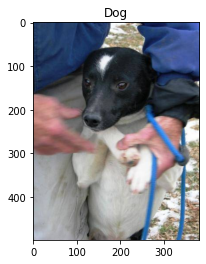

In [21]:
test_fnames = os.listdir(test_dir)
result = []

for fnames in test_fnames:
    pred_path = os.path.join(test_dir,fnames)
    title = pred(pred_path,True)
    value = 0
    if (title=='Dog'):
        value = 1
    tup = (pred_path,value)
    result.append(tup)
    break